In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("✅ Packages imported successfully!")

✅ Packages imported successfully!


## 1. Load Model Results

In [ ]:
# ==========================================
# LOAD MODEL RESULTS FROM PKL FILES
# ==========================================

print("Loading model results...")

# Load all model pkl files
# Note: Adjust the file paths as necessary
# use the model files without _ng suffix when you want non-handtuned versions, pure gridSearch results
# use the ones with _ng suffix when you want hand-tuned versions, less overfitting
# e.g.:
# models_data = {
#     'SVM': joblib.load('../models/svm_binary_dimensions_upsampled_ng.pkl'),
#     'Logistic Regression': joblib.load('../models/logistic_regression_binary_dimensions_optimal_ng.pkl'),
#     'Naive Bayes (BOW)': joblib.load('../models/naive_bayes_BOW_stability_ng.pkl'),
#     'Naive Bayes (TF-IDF)': joblib.load('../models/naive_bayes_IDF_stability_ng.pkl')
# }

models_data = {
    'SVM': joblib.load('../models/svm_binary_dimensions_upsampled.pkl'),
    'Logistic Regression': joblib.load('../models/logistic_regression_binary_dimensions_optimal.pkl'),
    'Naive Bayes (BOW)': joblib.load('../models/naive_bayes_BOW_stability.pkl'),
    'Naive Bayes (TF-IDF)': joblib.load('../models/naive_bayes_IDF_stability.pkl')
}

print(f"✅ Loaded {len(models_data)} models:")
for model_name in models_data.keys():
    print(f"   - {model_name}")

# Extract dimensions (should be same for all models)
dimensions = models_data['SVM']['dimensions']
print(f"✅ Dimensions: {dimensions}")

Loading model results...
✅ Loaded 4 models:
   - SVM
   - Logistic Regression
   - Naive Bayes (BOW)
   - Naive Bayes (TF-IDF)
✅ Dimensions: ['I/E', 'N/S', 'T/F', 'J/P']


## 2. F1-Score Comparison per Dimension

Compare F1-scores across all models for each MBTI dimension.
F1-score is preferred over accuracy for imbalanced classification tasks.

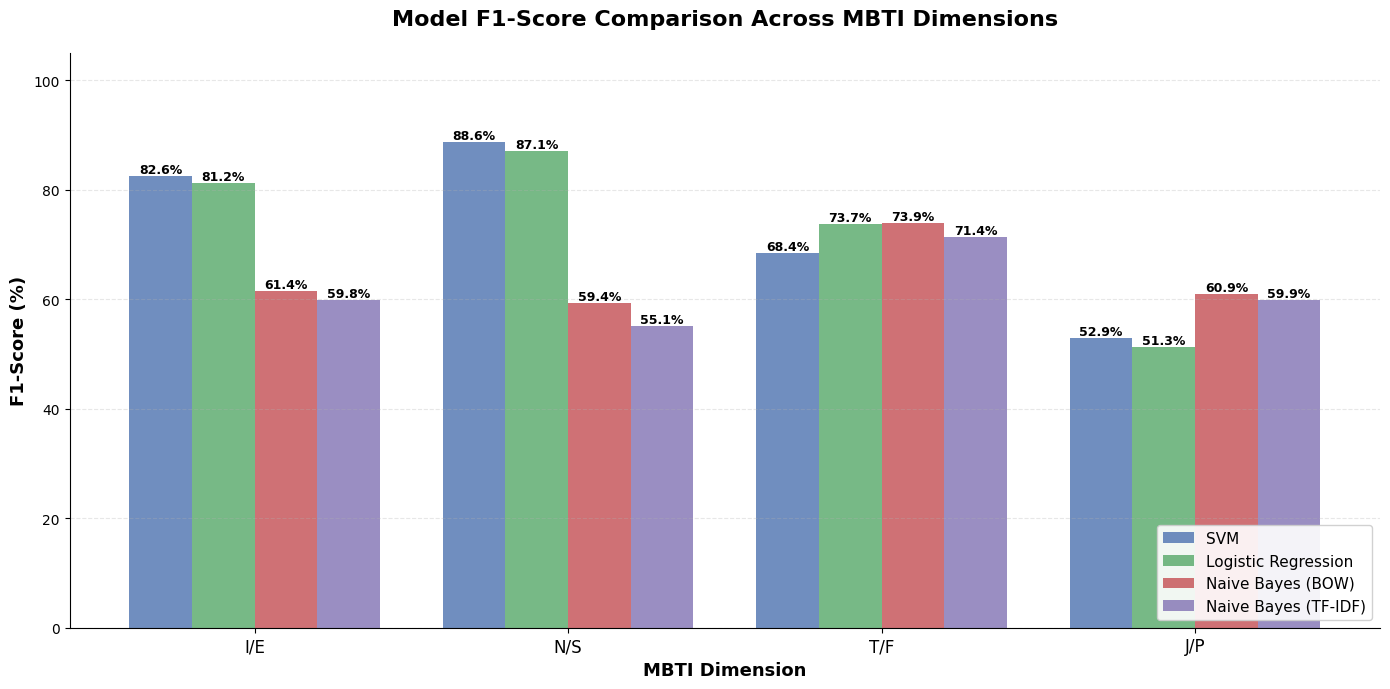


✅ F1-Score comparison chart generated!


In [18]:
# Extract F1-scores for each model and dimension
f1_data = []

for model_name, model_info in models_data.items():
    for dim in dimensions:
        f1_score = model_info['metrics'][dim]['f1_score']
        f1_data.append({
            'Model': model_name,
            'Dimension': dim,
            'F1-Score': f1_score
        })

f1_df = pd.DataFrame(f1_data)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

# Set up positions for grouped bars
x = np.arange(len(dimensions))
width = 0.2
model_names = list(models_data.keys())
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

# Plot bars for each model
for i, model_name in enumerate(model_names):
    model_f1_scores = [f1_df[(f1_df['Model'] == model_name) & 
                             (f1_df['Dimension'] == dim)]['F1-Score'].values[0] 
                       for dim in dimensions]
    bars = ax.bar(x + i * width, model_f1_scores, width, label=model_name, color=colors[i], alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize plot
ax.set_xlabel('MBTI Dimension', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score (%)', fontsize=13, fontweight='bold')
ax.set_title('Model F1-Score Comparison Across MBTI Dimensions', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(dimensions, fontsize=12)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✅ F1-Score comparison chart generated!")

## 3. Overfitting Analysis

Compare train vs. test performance to identify which models generalize well vs. overfit to training data.

SVM
Logistic Regression
Naive Bayes (BOW)
Naive Bayes (TF-IDF)


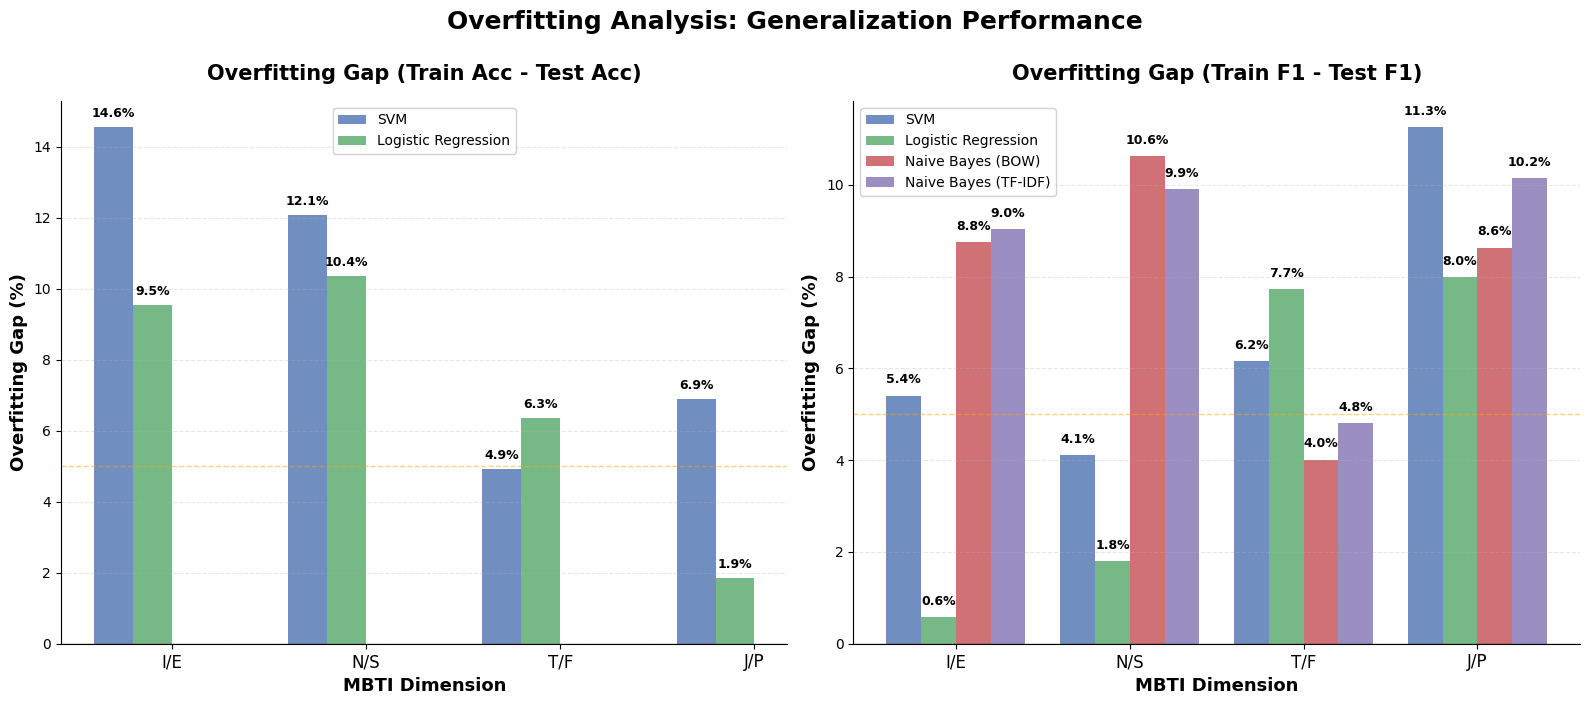

In [ ]:
# Extract overfitting gap (train_accuracy - test_accuracy) for each model
# note: for Naive Bayes models, we didnt manage to store train accuracies, due to a technical issue that's why we dont show them here

overfitting_data = []

for model_name, model_info in models_data.items():
    for dim in dimensions:
        
        
        # F1-score overfitting gap
        if model_name == 'Naive Bayes (BOW)' or model_name == 'Naive Bayes (TF-IDF)':
            test_f1 = model_info['metrics'][dim]['f1_score']
            overfit_gap_f1 = model_info['metrics'][dim]['overfit_gap']   # Use pre-computed gap from stability optimization

            overfitting_data.append({
                'Model': model_name,
                'Dimension': dim,
                'Test F1': test_f1,
                'Overfitting Gap (F1)': overfit_gap_f1
            })
        else:
            train_acc = model_info['metrics'][dim]['train_accuracy']
            test_acc = model_info['metrics'][dim]['accuracy']
            overfit_gap_acc = model_info['metrics'][dim]['overfit_gap']
            train_f1 = model_info['metrics'][dim]['train_f1']
            test_f1 = model_info['metrics'][dim]['f1_score']
            overfit_gap_f1 = train_f1 - test_f1

            overfitting_data.append({
            'Model': model_name,
            'Dimension': dim,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Overfitting Gap (Acc)': overfit_gap_acc,
            'Train F1': train_f1,
            'Test F1': test_f1,
            'Overfitting Gap (F1)': overfit_gap_f1
        })
        
        


overfit_df = pd.DataFrame(overfitting_data)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Set up common variables
x = np.arange(len(dimensions))
width = 0.2
model_names = list(models_data.keys())
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

# --- Left plot: Accuracy Overfitting Gap ---
for i, model_name in enumerate(model_names):
    print(model_name)
    if model_name == 'Naive Bayes (BOW)' or model_name == 'Naive Bayes (TF-IDF)':
        continue  # Skip Naive Bayes (BOW) and Naive Bayes (TF-IDF) for this plot
    else:
        model_gaps = [overfit_df[(overfit_df['Model'] == model_name) & 
                                (overfit_df['Dimension'] == dim)]['Overfitting Gap (Acc)'].values[0] 
                    for dim in dimensions]
        bars = ax1.bar(x + i * width, model_gaps, width, label=model_name, color=colors[i], alpha=0.8)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('MBTI Dimension', fontsize=13, fontweight='bold')
ax1.set_ylabel('Overfitting Gap (%)', fontsize=13, fontweight='bold')
ax1.set_title('Overfitting Gap (Train Acc - Test Acc)', fontsize=15, fontweight='bold', pad=15)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(dimensions, fontsize=12)
ax1.legend(loc='upper center', fontsize=10, framealpha=0.9)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax1.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right plot: F1-Score Overfitting Gap ---
for i, model_name in enumerate(model_names):
    model_gaps_f1 = [overfit_df[(overfit_df['Model'] == model_name) & 
                                (overfit_df['Dimension'] == dim)]['Overfitting Gap (F1)'].values[0] 
                     for dim in dimensions]
    bars = ax2.bar(x + i * width, model_gaps_f1, width, label=model_name, color=colors[i], alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xlabel('MBTI Dimension', fontsize=13, fontweight='bold')
ax2.set_ylabel('Overfitting Gap (%)', fontsize=13, fontweight='bold')
ax2.set_title('Overfitting Gap (Train F1 - Test F1)', fontsize=15, fontweight='bold', pad=15)
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(dimensions, fontsize=12)
ax2.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Overfitting Analysis: Generalization Performance', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()